# Llama-2 Generation Test with Jungle Attention

**Purpose:** Early-stage integration test of Jungle attention mechanism with Llama-2-7b-chat model.

**What it does:**
- Loads Llama-2-7b-chat and replaces attention with sparse LSH-based mechanism
- Tests both MagicPIG (fixed-depth K=8, threshold=2) and Jungle (forest-based K=10, min_depth=10)
- Performs text generation to validate end-to-end functionality
- Measures basic statistics (tokens retrieved, tree depths used)

**Purpose:** Validates that the sparse attention mechanism can successfully generate coherent text and serves as a sanity check before full evaluation.

In [1]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- 1. Device Setup ---
if torch.cuda.is_available():
    model_device = "cuda"
elif torch.backends.mps.is_available():
    model_device = "mps"
else:
    model_device = "cpu"

print(f"Using model device: {model_device}")
sim_device = torch.device("cpu") 

# --- 2. Load Model ---
model_name = "NousResearch/Llama-2-7b-chat-hf"
print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if model_device != "cpu" else torch.float32,
    device_map=model_device,
    use_cache=True
)
model.eval()

# --- 3. Constants (Adjusted for Hybrid & Short Seq) ---
LAYER_ID = model.config.num_hidden_layers - 1 
HEAD_DIM = 128
L_TREES = 100          

# MagicPIG
K_MAGIC = 8            
MAGIC_THRESHOLD = 2    

# Jungle: Adjusted for short sequence test
K_JUNGLE = 10           
JUNGLE_MIN_DEPTH = 10  

# Generate Projections
rng_gen = torch.Generator().manual_seed(42)
MAX_K = max(K_MAGIC, K_JUNGLE)
projections = torch.randn((HEAD_DIM, L_TREES * MAX_K), generator=rng_gen).to(sim_device)

print(f"\n--- Configuration ---\nL_TREES: {L_TREES}")
print(f"MagicPIG: K={K_MAGIC}, Threshold={MAGIC_THRESHOLD}")
print(f"Jungle:   K={K_JUNGLE}, Min_Depth={JUNGLE_MIN_DEPTH} (Forest Active)")

Using model device: mps
Loading NousResearch/Llama-2-7b-chat-hf...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


--- Configuration ---
L_TREES: 100
MagicPIG: K=8, Threshold=2
Jungle:   K=10, Min_Depth=10 (Forest Active)


In [2]:
def calculate_angle(q, k):
    """Computes angle theta between query and keys."""
    dot = (q * k).sum(dim=-1)
    norms = torch.norm(q, dim=-1) * torch.norm(k, dim=-1)
    cos_sim = (dot / (norms + 1e-8)).clamp(-1.0, 1.0)
    return torch.acos(cos_sim)

def prob_magic_pig_survival(theta, L, K, T=2):
    """
    Probability of colliding in at least T out of L tables.
    """
    p_simhash = 1.0 - (theta / torch.pi)
    p_table = p_simhash.pow(K)
    
    # Probability of failure (0 to T-1 collisions)
    p_fail_cum = torch.zeros_like(theta)
    for k in range(T):
        comb = math.comb(L, k)
        log_p = math.log(comb) + k * torch.log(p_table + 1e-10) + (L - k) * torch.log(1 - p_table + 1e-10)
        p_fail_cum += torch.exp(log_p)
        
    return (1.0 - p_fail_cum).clamp(min=1e-6)

def prob_jungle_unbiased(theta, L, d_min):
    """
    Probability for Forest/Jungle retrieval.
    Union of L trees: P(any tree matches >= d_min)
    Formula: 1 - (1 - p^d)^L
    """
    p_simhash = 1.0 - (theta / torch.pi)
    p_depth = p_simhash.pow(d_min) 
    
    # Prob of match in at least one tree
    u = 1.0 - (1.0 - p_depth).pow(L)
    
    return u.clamp(min=1e-6)

In [3]:
def run_simulation(method_name, prompt_text, steps=30):
    input_ids = tokenizer(prompt_text, return_tensors="pt").input_ids.to(model.device)
    curr_ids = input_ids.clone()
    past_kv = None
    
    diagnostics = {
        "error": [], "num_candidates": [], "total_keys": [],
        "selected_indices": [], "compute_ratio": []     
    }
    
    k_full_cpu = None
    v_full_cpu = None
    
    print(f"--- Running {method_name} ---\n")
    previous_text = tokenizer.decode(curr_ids[0], skip_special_tokens=True)
    
    for step_i in range(steps):
        # 1. Forward Pass
        if past_kv is None:
            model_inputs = {"input_ids": curr_ids}
        else:
            model_inputs = {"input_ids": curr_ids[:, -1:], "past_key_values": past_kv}

        with torch.no_grad():
            outputs = model(**model_inputs, use_cache=True, output_hidden_states=True)
        
        h_in = outputs.hidden_states[LAYER_ID][:, -1:, :] 
        layer = model.model.layers[LAYER_ID]
        
        # 2. Get Q, K, V
        h_in_normed = layer.input_layernorm(h_in)
        q_out = layer.self_attn.q_proj(h_in_normed)
        k_out = layer.self_attn.k_proj(h_in_normed)
        v_out = layer.self_attn.v_proj(h_in_normed)
        
        q_cpu = q_out.view(1, 1, 32, 128).transpose(1, 2).squeeze(0).squeeze(1).detach().to(sim_device).float()
        k_new = k_out.view(1, 1, 32, 128).transpose(1, 2).squeeze(0).squeeze(1).detach().to(sim_device).float()
        v_new = v_out.view(1, 1, 32, 128).transpose(1, 2).squeeze(0).squeeze(1).detach().to(sim_device).float()

        if k_full_cpu is None:
            k_full_cpu = k_new.unsqueeze(1)
            v_full_cpu = v_new.unsqueeze(1)
        else:
            k_full_cpu = torch.cat([k_full_cpu, k_new.unsqueeze(1)], dim=1)
            v_full_cpu = torch.cat([v_full_cpu, v_new.unsqueeze(1)], dim=1)

        num_heads, seq_len, head_dim = k_full_cpu.shape

        # 3. Ground Truth
        scores = (q_cpu.unsqueeze(1) @ k_full_cpu.transpose(-1, -2)) / math.sqrt(head_dim)
        ref_out = torch.softmax(scores, dim=-1) @ v_full_cpu 

        # 4. Approximation with Hybrid Strategy
        approx_out = torch.zeros_like(ref_out)
        step_indices_set = set()
        
        if method_name == "Full":
            approx_out = ref_out
            step_indices_set = set(range(seq_len))
        else:
            curr_K = K_MAGIC if method_name == "MagicPIG" else K_JUNGLE
            curr_projs = projections[:, :L_TREES * curr_K]
            
            # Center for Hash
            if seq_len > 1:
                k_mean = k_full_cpu.mean(dim=1, keepdim=True)
                k_centered = k_full_cpu - k_mean
                q_centered = q_cpu.unsqueeze(1) - k_mean 
            else:
                k_centered = k_full_cpu
                q_centered = q_cpu.unsqueeze(1)

            # Hash Centered Vectors
            k_hash = (k_centered @ curr_projs) >= 0
            q_hash = (q_centered @ curr_projs) >= 0
            
            k_bits = k_hash.view(num_heads, seq_len, L_TREES, curr_K)
            q_bits = q_hash.view(num_heads, 1, L_TREES, curr_K)

            # --- HYBRID STRATEGY: Mandatory Indices ---
            # Always keep Sink (first 4) and Local (last 10)
            n_sink = 4
            n_local = 10
            sink_idxs = torch.arange(0, min(n_sink, seq_len), device=sim_device)
            local_idxs = torch.arange(max(0, seq_len - n_local), seq_len, device=sim_device)
            mandatory_indices = torch.cat([sink_idxs, local_idxs]).unique()
            u_mandatory = torch.ones(len(mandatory_indices), device=sim_device)

            for h in range(num_heads):
                lsh_indices = torch.tensor([], device=sim_device, dtype=torch.long)
                u_lsh = torch.tensor([], device=sim_device)

                if method_name == "MagicPIG":
                    matches = (k_bits[h] == q_bits[h]).all(dim=-1)
                    collisions = matches.sum(dim=-1)
                    lsh_indices = torch.nonzero(collisions >= MAGIC_THRESHOLD).squeeze(-1)
                    
                    if len(lsh_indices) > 0:
                        theta = calculate_angle(q_centered[h], k_centered[h, lsh_indices])
                        u_lsh = prob_magic_pig_survival(theta, L_TREES, K_MAGIC, MAGIC_THRESHOLD)

                elif method_name == "Jungle":
                    xor_res = (k_bits[h] ^ q_bits[h].squeeze(0)).int()
                    depths = (xor_res.cumsum(dim=-1) == 0).sum(dim=-1) # [Seq, L]
                    max_d = depths.max(dim=-1).values
                    lsh_indices = torch.nonzero(max_d >= JUNGLE_MIN_DEPTH).squeeze(-1)
                    
                    if len(lsh_indices) > 0:
                        theta = calculate_angle(q_centered[h], k_centered[h, lsh_indices])
                        d_vals = max_d[lsh_indices]
                        u_lsh = prob_jungle_unbiased(theta, L_TREES, d_vals)

                # Merge Sets (Hybrid)
                if len(lsh_indices) > 0:
                    # Filter LSH indices that are NOT in mandatory (to avoid dups/prob issues)
                    mask_new = ~torch.isin(lsh_indices, mandatory_indices)
                    pure_lsh_idx = lsh_indices[mask_new]
                    pure_lsh_u = u_lsh[mask_new]
                    
                    final_indices = torch.cat([mandatory_indices, pure_lsh_idx])
                    final_u = torch.cat([u_mandatory, pure_lsh_u])
                else:
                    final_indices = mandatory_indices
                    final_u = u_mandatory
                
                # Sort for stability (optional but good for debugging)
                sort_idx = torch.argsort(final_indices)
                final_indices = final_indices[sort_idx]
                final_u = final_u[sort_idx]

                if h == 0: step_indices_set.update(final_indices.tolist())

                # Weighted Attention (SNIS)
                k_sub = k_full_cpu[h, final_indices] 
                v_sub = v_full_cpu[h, final_indices]
                q_vec = q_cpu[h] 
                
                # Raw dot product (uncentered)
                logits = (q_vec @ k_sub.T) / math.sqrt(head_dim)
                
                # Safe Softmax
                w_i = torch.exp(logits - logits.max())
                
                # Importance Sampling Weighting
                r_i = w_i / (final_u + 1e-10)
                
                weighted_sum = r_i @ v_sub 
                approx_out[h] = weighted_sum / (r_i.sum() + 1e-10)

        # 5. Metrics
        err = torch.norm(approx_out - ref_out) / (torch.norm(ref_out) + 1e-6)
        
        diagnostics["error"].append(err.item())
        diagnostics["num_candidates"].append(len(step_indices_set))
        diagnostics["total_keys"].append(seq_len)
        diagnostics["selected_indices"].append(step_indices_set)
        diagnostics["compute_ratio"].append(len(step_indices_set) / seq_len)

        # 6. Inject 
        attn_res = approx_out.unsqueeze(0).transpose(1, 2).reshape(1, 1, 4096).to(model.device).to(h_in.dtype)
        attn_proj = layer.self_attn.o_proj(attn_res)
        res = h_in + attn_proj
        normed = layer.post_attention_layernorm(res)
        mlp_out = layer.mlp(normed)
        next_h = res + mlp_out
        
        for next_i in range(LAYER_ID + 1, len(model.model.layers)):
            next_h = model.model.layers[next_i](next_h)[0]
        next_h = model.model.norm(next_h)
        logits = model.lm_head(next_h)
        next_id = torch.argmax(logits[:, -1, :], dim=-1)
        curr_ids = torch.cat([curr_ids, next_id.unsqueeze(0)], dim=-1)
        
        current_text = tokenizer.decode(curr_ids[0], skip_special_tokens=True)
        print(current_text[len(previous_text):], end="", flush=True)
        previous_text = current_text
        past_kv = outputs.past_key_values
        if next_id.item() == tokenizer.eos_token_id: break

    print("\n")
    return diagnostics

--- Running Full ---

 

We detected that you are passing `past_key_values` as a tuple of tuples. This is deprecated and will be removed in v4.47. Please convert your cache or use an appropriate `Cache` class (https://huggingface.co/docs/transformers/kv_cache#legacy-cache-format)


 Sure, here's a humorous story about three individuals who walk into a bar:

It was a typical Tuesday evening at the local watering hole, the "Drunken Goat," and the bar was bustling with patrons. That is, until three peculiar individuals walked in and took up residence at the bar.

First, there was Bob, a tall, lanky man with a mop of curly hair and a perpetual five

--- Running MagicPIG ---

  Sure, here's a humorous story about three individuals who walk into a bar:

It was a typical Tuesday evening and the local watering hole, "Murphy's Tavern," was bustling with activity. The bar was filled with the usual suspects, sipping on their drinks and engaging in lively conversations. That was, until three peculiar individuals walked in and turned the atmosphere upside down.

The first individual,

--- Running Jungle ---

  Sure, here's a humorous story about three individuals who walk into a bar:

It was a typical Tuesday evening and the bar was bustling with patrons. The bartender, a gru

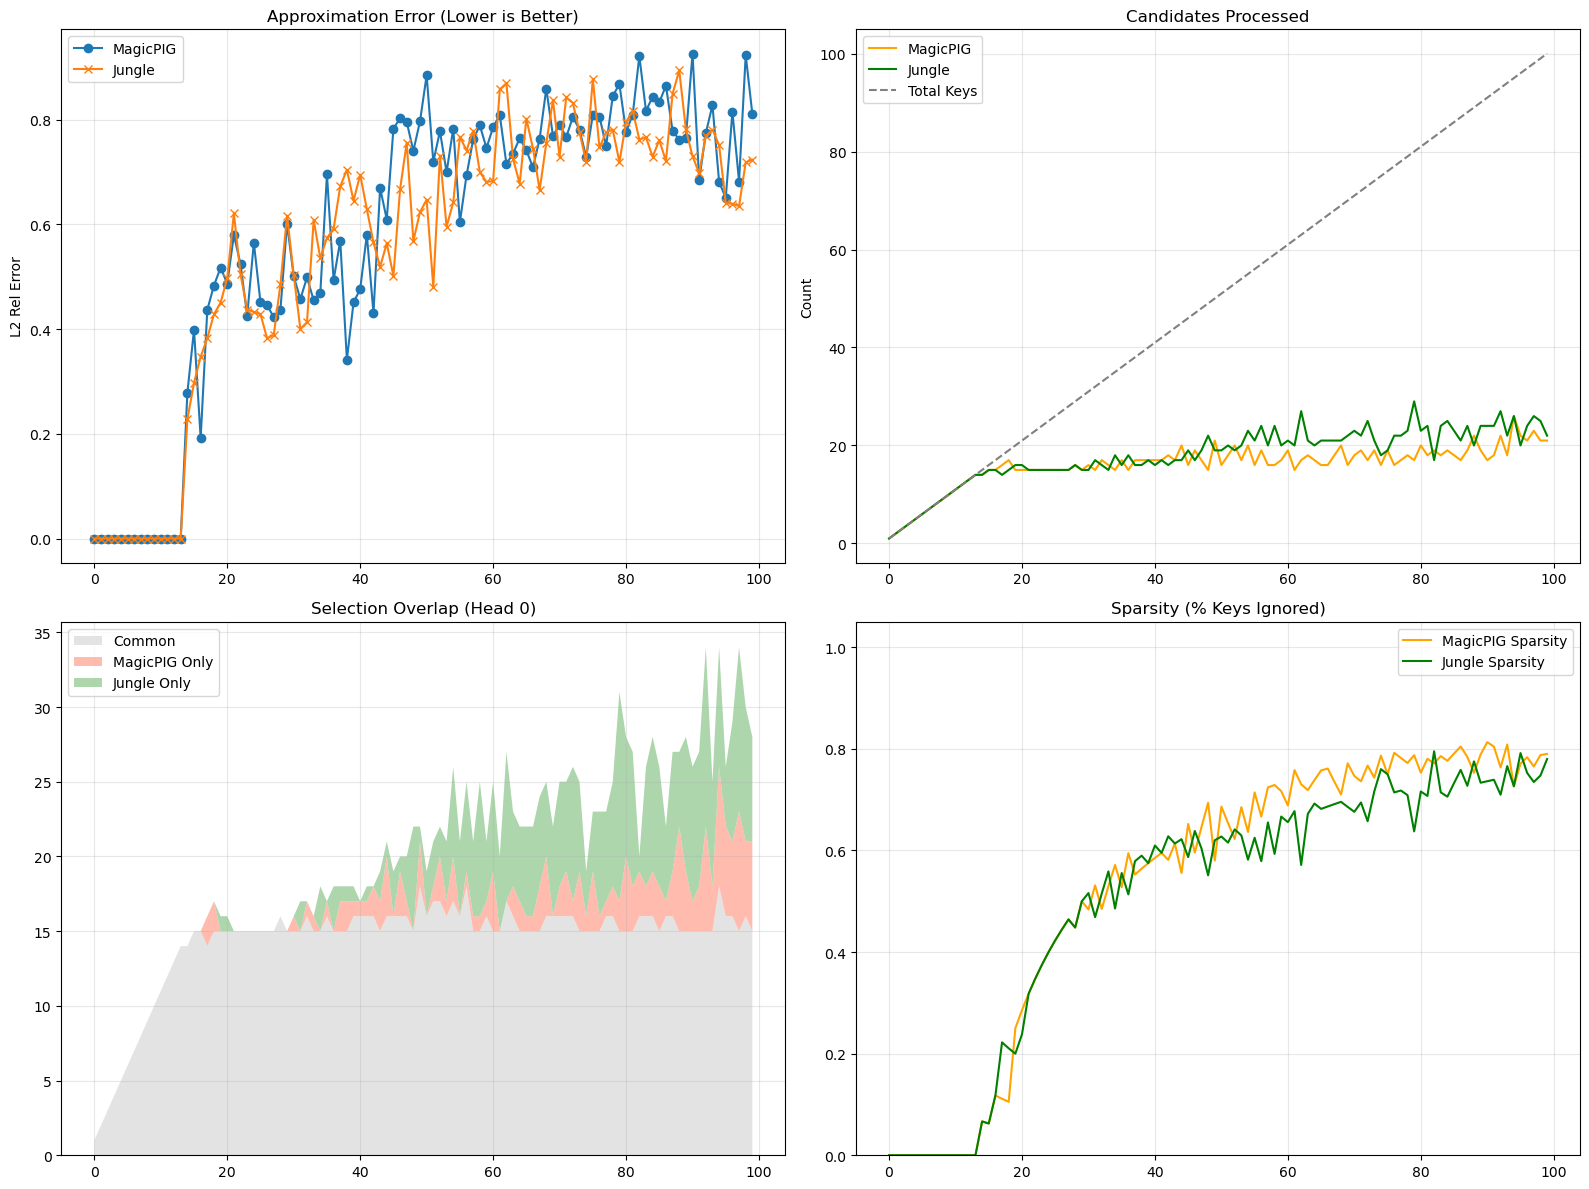

MagicPIG Avg Error: 0.5789
Jungle   Avg Error: 0.5583


In [4]:
# 1. Setup Prompt
prompt = "Write a story about 3 individuals who walk into a bar. The story should be humorous, and funny."
full_prompt = f"[INST] {prompt} [/INST]"

results = {}

# 2. Run
results["Full"] = run_simulation("Full", full_prompt, steps=100)
results["MagicPIG"] = run_simulation("MagicPIG", full_prompt, steps=100)
results["Jungle"] = run_simulation("Jungle", full_prompt, steps=100)

# 3. Analyze Overlap (Head 0)
n_steps = len(results["Full"]["error"])
overlap_counts = []
magic_only = []
jungle_only = []

for i in range(n_steps):
    set_m = results["MagicPIG"]["selected_indices"][i]
    set_j = results["Jungle"]["selected_indices"][i]
    
    common = set_m.intersection(set_j)
    overlap_counts.append(len(common))
    magic_only.append(len(set_m - set_j))
    jungle_only.append(len(set_j - set_m))

# 4. Plotting
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Error
ax = axes[0, 0]
ax.plot(results["MagicPIG"]["error"], label="MagicPIG", marker='o')
ax.plot(results["Jungle"]["error"], label="Jungle", marker='x')
ax.set_title("Approximation Error (Lower is Better)")
ax.set_ylabel("L2 Rel Error")
ax.legend()
ax.grid(True, alpha=0.3)

# B. Candidates
ax = axes[0, 1]
ax.plot(results["MagicPIG"]["num_candidates"], label="MagicPIG", color="orange")
ax.plot(results["Jungle"]["num_candidates"], label="Jungle", color="green")
ax.plot(results["Full"]["total_keys"], label="Total Keys", color="gray", linestyle="--")
ax.set_title("Candidates Processed")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)

# C. Overlap
ax = axes[1, 0]
x = range(n_steps)
ax.stackplot(x, overlap_counts, magic_only, jungle_only,
             labels=['Common', 'MagicPIG Only', 'Jungle Only'],
             colors=['#dddddd', '#ffaa99', '#99cc99'], alpha=0.8)
ax.set_title("Selection Overlap (Head 0)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# D. Sparsity
ax = axes[1, 1]
magic_sparsity = [1.0 - r for r in results["MagicPIG"]["compute_ratio"]]
jungle_sparsity = [1.0 - r for r in results["Jungle"]["compute_ratio"]]
ax.plot(magic_sparsity, label="MagicPIG Sparsity", color="orange")
ax.plot(jungle_sparsity, label="Jungle Sparsity", color="green")
ax.set_title("Sparsity (% Keys Ignored)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats
print(f"MagicPIG Avg Error: {np.mean(results['MagicPIG']['error']):.4f}")
print(f"Jungle   Avg Error: {np.mean(results['Jungle']['error']):.4f}")